# NAB Anomaly Detection — EDA 

**Project:** Anomaly detection on real AWS CloudWatch time series (NAB `realAWSCloudwatch` dataset).

**This notebook covers the exploratory data analysis (EDA):**
1. Loading a single series (`ec2_cpu_utilization_825cc2.csv`) and its labeled anomaly windows
2. Basic statistics and full-series visualization
3. Data quality checks (duplicates, missing timestamps) and cleaning
4. Zoomed analysis of the anomaly region
5. Seasonal decomposition and rolling statistics as candidate features
6. Cross-file comparison to assess pattern diversity across the dataset
7. A closer look at a harder, subtle anomaly case (`ec2_cpu_utilization_53ea38.csv`)


## Imports + data loading

In [16]:
import sys 
sys.path.append("..")
import pandas as pd
import matplotlib.pyplot as plt
from src.data_loading import load_series, load_anomaly_windows

FILENAME = "ec2_cpu_utilization_825cc2.csv"

df = load_series(FILENAME)
windows = load_anomaly_windows(FILENAME)

df.head()

,value
timestamp,
2014-04-10 00:04:00,91.958
2014-04-10 00:09:00,94.798
2014-04-10 00:14:00,92.208
2014-04-10 00:19:00,93.722
2014-04-10 00:24:00,93.042


## Basic info + stats

In [9]:
print(f"Shape: {df.shape}")
print(f"Time range: {df.index.min()} -> {df.index.max()}")
print(f"Sampling frequency (most common delta):")
print(df.index.to_series().diff().value_counts().head())
print()
print("Descriptive statistics:")
df.describe()

Shape: (4032, 1)
Time range: 2014-04-10 00:04:00 -> 2014-04-24 00:09:00
Sampling frequency (most common delta):
timestamp
0 days 00:05:00    4029
0 days 00:10:00       2
Name: count, dtype: int64

Descriptive statistics:


,value
count,4032.000000
mean,89.791262
std,12.078708
min,18.722500
25%,89.081000
50%,92.449000
75%,94.299500
max,99.118000


## Plot with anomaly window highlighted

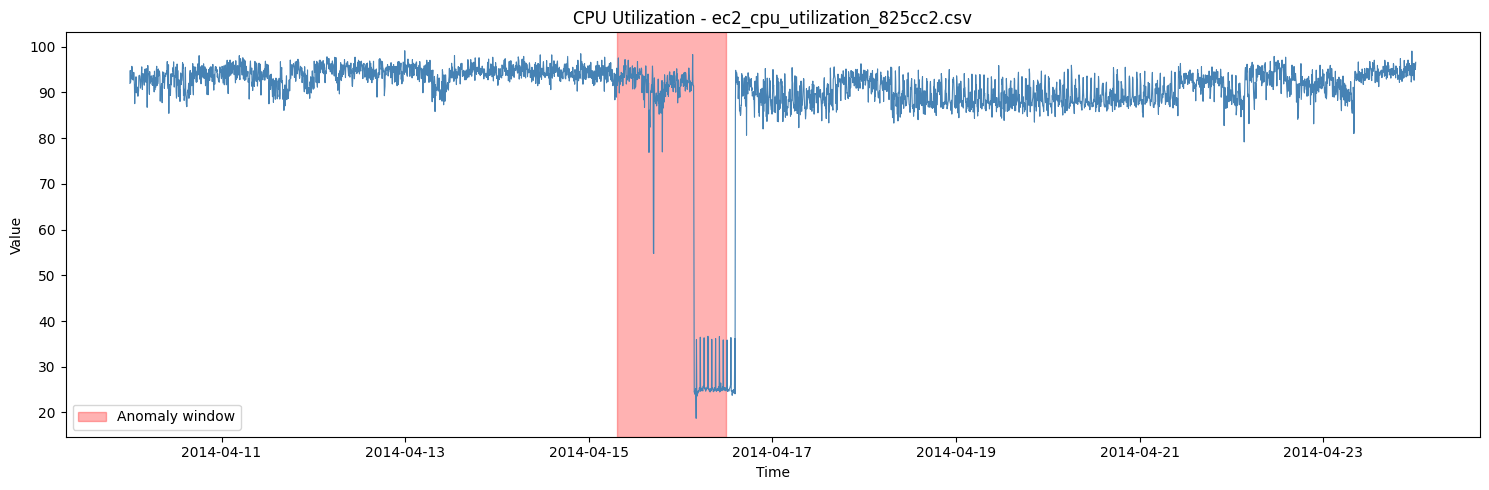

In [15]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df.index, df["value"], linewidth=0.8, color="steelblue")

for start, end in windows:
    ax.axvspan(start, end, color="red", alpha=0.3, label="Anomaly window")

ax.set_title(f"CPU Utilization - {FILENAME}")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())
plt.tight_layout()
plt.show()


### Interpretation of the Results

The CPU operates under a consistently high load during normal conditions, with values generally ranging from **85% to 98%** (mean: **89.8%**, standard deviation: **12%**). This indicates that high CPU utilization is the normal baseline for this server.

The dataset is almost uniformly sampled every **5 minutes**, with only **two 10-minute gaps**, suggesting a few missing timestamps that should be considered when using window-based methods.

The anomaly begins with a **progressive decrease** in CPU utilization within the labeled anomaly window, followed by a **more pronounced drop and sawtooth fluctuations** immediately after the labeled period. The CPU gradually recovers to its normal level around **April 21–22**.

This suggests that the labeled anomaly window captures the **onset** of the abnormal behavior but not its entire duration.


## Duplicate and missing data checking

In [22]:
n_duplicates = df.index.duplicated().sum()
print(f"Duplicated timestamps: {n_duplicates}")

expected_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq="5min")
print(f"Expected number of points at 5-min freq: {len(expected_index)}")
print(f"Actual number of points: {len(df)}")
print(f"Missing points: {len(expected_index) - len(df)}")

missing_timestamps = expected_index.difference(df.index)
print(f"\nMissing timestamps ({len(missing_timestamps)}):")
print(missing_timestamps)

Duplicated timestamps: 0
Expected number of points at 5-min freq: 4034
Actual number of points: 4032
Missing points: 2

Missing timestamps (2):
DatetimeIndex(['2014-04-10 03:14:00', '2014-04-13 21:04:00'], dtype='datetime64[us]', freq=None)


### Data Quality Check

No duplicate timestamps found. Only 2 timestamps are missing out of 4034 expected points on the 5-minute grid, both located far from the anomaly window — negligible impact, handled by linear interpolation below.

### Reindex on a complete 5min grid and interpolate the 2 missing points

In [23]:
df_clean = df.reindex(expected_index)
df_clean.index.name = "timestamp"

print(f"Missing values before interpolation: {df_clean['value'].isna().sum()}")

df_clean["value"] = df_clean["value"].interpolate(method="linear")

print(f"Missing valyes after interpolation: {df_clean['value'].isna().sum()}")
print(f"Shape: {df_clean.shape}")

Missing values before interpolation: 2
Missing valyes after interpolation: 0
Shape: (4034, 1)


### Cleaning Note

The series is now reindexed on a complete 5-minute grid with the 2 missing points linearly interpolated. `df_clean` is used for all subsequent analysis in this notebook.

## Zoom on the anomaly window and the sawtooth region right after it

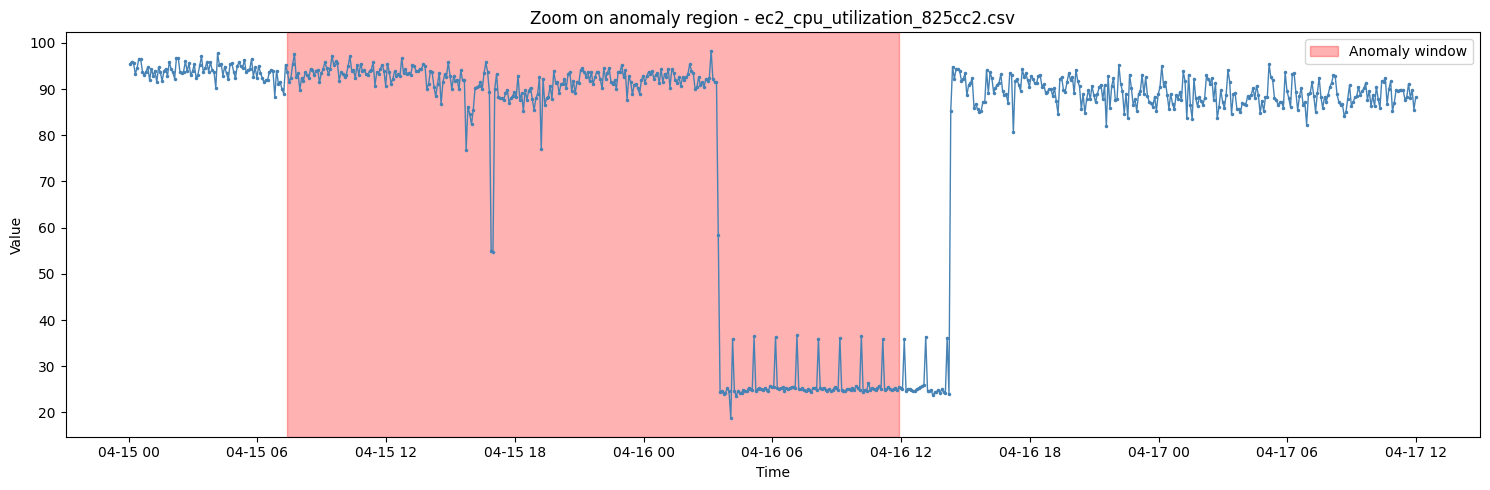

In [25]:
zoom_start = pd.Timestamp("2014-04-15 00:00:00")
zoom_end = pd.Timestamp("2014-04-17 12:00:00")

df_zoom = df_clean.loc[zoom_start:zoom_end]

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df_zoom.index, df_zoom["value"], linewidth=1, color="steelblue", marker=".", markersize=3)

for start, end in windows:
    ax.axvspan(start, end, color="red", alpha=0.3, label="Anomaly window")

ax.set_title(f"Zoom on anomaly region - {FILENAME}")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())
plt.tight_layout()
plt.show()

### Interpretation of the Anomaly Zoom

The zoomed visualization reveals four main phases:

- **Before the anomaly (15/04 ~06:00):**  
  CPU utilization remains stable around **90–95%**, with only two short drops (~77% and ~55%). These are isolated events and do not represent a change in behavior.

- **Main anomaly event (16/04 ~05:00):**  
  A sharp decrease from approximately **90% to 25%** indicates a major change in system activity.

- **Low CPU periodic regime (16/04 05:00 → ~13:30):**  
  The CPU remains low (**24–25%**) with regular peaks around **36%**, suggesting a structured periodic pattern rather than random noise.

- **Recovery phase (~16/04 13:30):**  
  CPU utilization returns to its normal range (**85–92%**).

The NAB anomaly window is well aligned with the abnormal behavior, covering the main drop and most of the recovery process, with only a short period of normal recovery after the label ends.

This example highlights two types of anomalies:
- **Point anomalies:** isolated abnormal values.
- **Contextual/time-series anomalies:** a persistent change in the temporal behavior of the signal.

This distinction will be important when comparing different anomaly detection approaches.

## Seasonal decomposition to check for a daily cycle

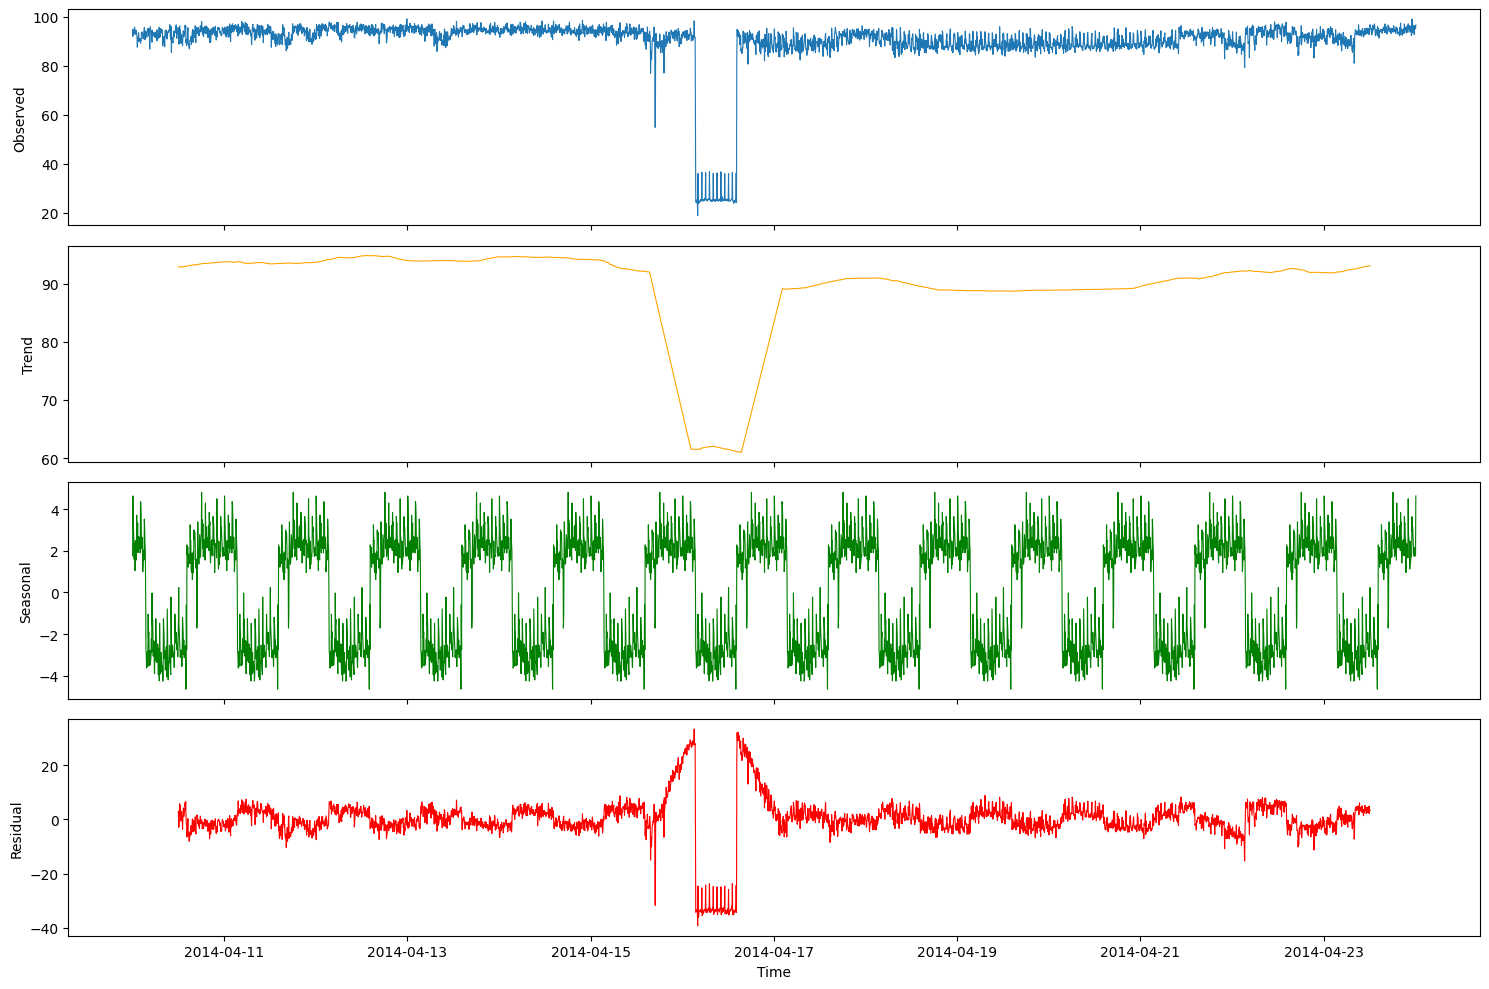

In [ ]:

from statsmodels.tsa.seasonal import seasonal_decompose

# 5-min frequency -> 288 points per day
PERIOD = 288

decomposition = seasonal_decompose(df_clean["value"], model="additive", period=PERIOD)

fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)
axes[0].plot(decomposition.observed, linewidth=0.8)
axes[0].set_ylabel("Observed")
axes[1].plot(decomposition.trend, linewidth=0.8, color="orange")
axes[1].set_ylabel("Trend")
axes[2].plot(decomposition.seasonal, linewidth=0.8, color="green")
axes[2].set_ylabel("Seasonal")
axes[3].plot(decomposition.resid, linewidth=0.8, color="red")
axes[3].set_ylabel("Residual")
axes[3].set_xlabel("Time")

plt.tight_layout()
plt.show()

### Seasonal Decomposition Analysis

The decomposition highlights three main components:

- **Trend:** The trend captures the overall CPU decrease during the anomaly (from ~93 to ~61). However, since the anomaly lasts around 30 hours and the selected seasonal period is 24 hours, part of the anomaly is absorbed into the trend component.

- **Seasonal:** A clear daily pattern is observed, with a small amplitude (around ±5). This indicates a slight daily variation in CPU usage, but it remains minor compared to the overall CPU level.

- **Residual:** The residual component is the most informative. It remains within a narrow range during normal operation but shows large deviations during the anomaly period (~+30/-35). This confirms that the anomalous behavior differs significantly from the normal pattern.

## Rolling statistics to characterize local signal behavior

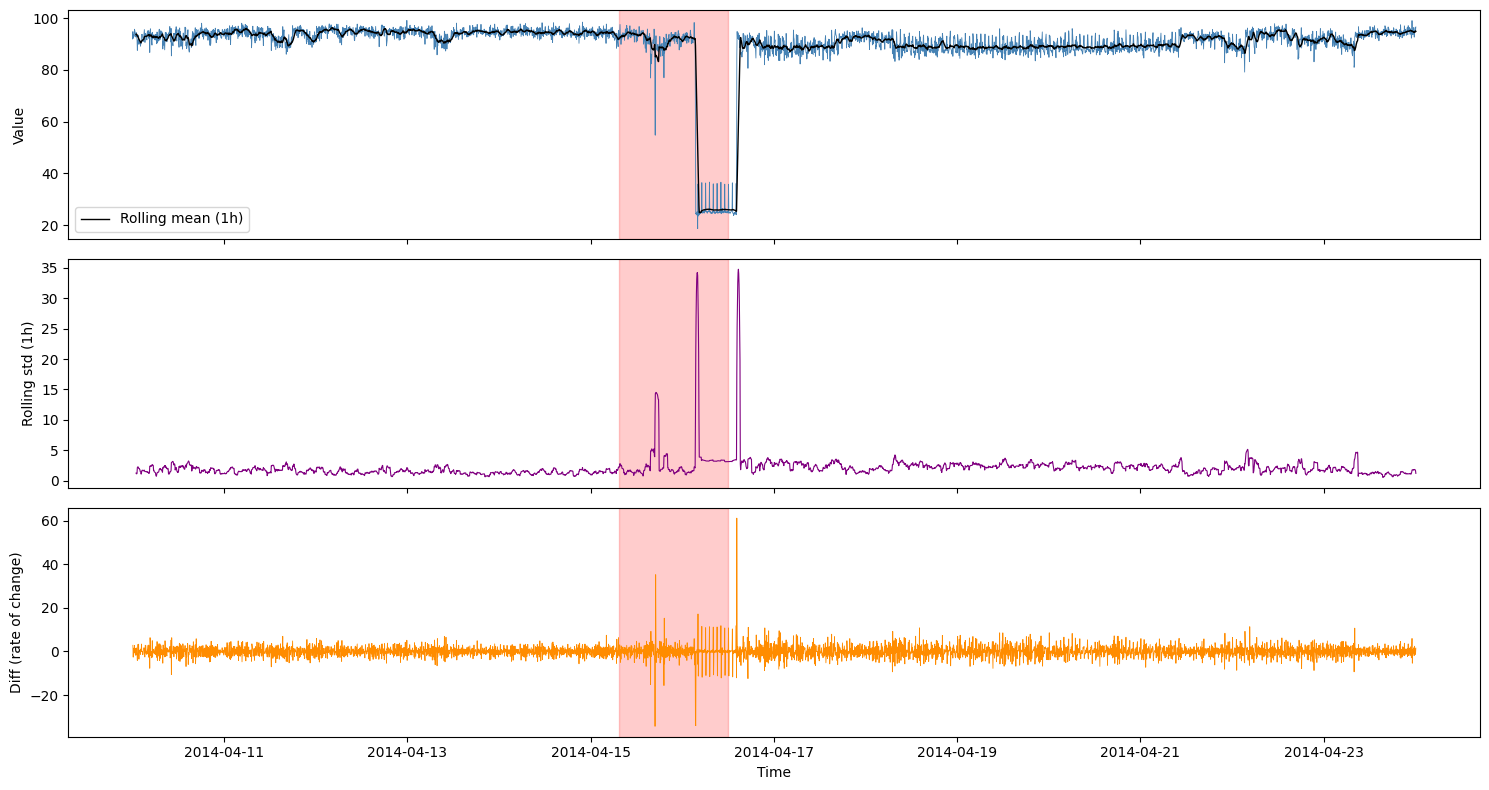

Diff statistics (rate of change between consecutive points):
count    4033.000000
mean        0.001147
std         2.999768
min       -34.334000
25%        -1.458000
50%        -0.046000
75%         1.418000
max        61.184000
Name: diff, dtype: float64


In [ ]:

WINDOW = 12  # 1 hour at 5-min frequency

df_clean["rolling_mean"] = df_clean["value"].rolling(WINDOW).mean()
df_clean["rolling_std"] = df_clean["value"].rolling(WINDOW).std()
df_clean["diff"] = df_clean["value"].diff()  # rate of change between consecutive points

fig, axes = plt.subplots(3, 1, figsize=(15, 8), sharex=True)

axes[0].plot(df_clean.index, df_clean["value"], linewidth=0.6, color="steelblue")
axes[0].plot(df_clean.index, df_clean["rolling_mean"], linewidth=1, color="black", label="Rolling mean (1h)")
axes[0].set_ylabel("Value")
axes[0].legend()

axes[1].plot(df_clean.index, df_clean["rolling_std"], linewidth=0.8, color="purple")
axes[1].set_ylabel("Rolling std (1h)")

axes[2].plot(df_clean.index, df_clean["diff"], linewidth=0.6, color="darkorange")
axes[2].set_ylabel("Diff (rate of change)")
axes[2].set_xlabel("Time")

for ax in axes:
    for start, end in windows:
        ax.axvspan(start, end, color="red", alpha=0.2)

plt.tight_layout()
plt.show()

print("Diff statistics (rate of change between consecutive points):")
print(df_clean["diff"].describe())

### Rolling Statistics Analysis

The rolling statistics reveal two important anomaly indicators:

- **Rolling standard deviation (1h):** This is the most discriminative feature observed so far. It remains low during normal operation (~1–4) but increases significantly during the anomaly period (up to ~35), indicating a strong change in CPU variability.

- **Point-to-point difference (`diff`):** The CPU changes are usually small, but extreme variations appear during the anomaly window (from about -34 to +61). These sudden changes are strong indicators of abnormal behavior and can be useful features for a baseline anomaly detection model such as Isolation Forest.

## Save the cleaned dataframe 

In [31]:

OUTPUT_PATH = Path("../data/processed") 
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

df_clean.to_csv(OUTPUT_PATH / f"clean_{FILENAME}")
print(f"Saved to {OUTPUT_PATH / f'clean_{FILENAME}'}")

Saved to ..\data\processed\clean_ec2_cpu_utilization_825cc2.csv


## Cross-File Comparison

Before moving to modeling, the same exploration pipeline (loading, cleaning, plotting) is applied to a few other `ec2_cpu_utilization` files, to check whether the patterns observed above generalize across the dataset.# check other datasets too

In [32]:
def explore_file(filename: str) -> pd.DataFrame:
    """Load, clean, summarize and plot a single NAB CSV file."""
    df = load_series(filename)
    windows = load_anomaly_windows(filename)

    # Reindex on complete 5-min grid and interpolate missing points
    expected_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq="5min")
    df_clean = df.reindex(expected_index)
    df_clean.index.name = "timestamp"
    n_missing = df_clean["value"].isna().sum()
    df_clean["value"] = df_clean["value"].interpolate(method="linear")

    # Summary
    print(f"=== {filename} ===")
    print(f"Shape: {df_clean.shape} | Missing points interpolated: {n_missing}")
    print(f"Value range: [{df_clean['value'].min():.1f}, {df_clean['value'].max():.1f}] | "
          f"Mean: {df_clean['value'].mean():.1f} | Std: {df_clean['value'].std():.1f}")
    print(f"Number of anomaly windows: {len(windows)}")
    for start, end in windows:
        print(f"  - {start} -> {end}  (duration: {end - start})")

    # Plot
    fig, ax = plt.subplots(figsize=(15, 4))
    ax.plot(df_clean.index, df_clean["value"], linewidth=0.7, color="steelblue")
    for start, end in windows:
        ax.axvspan(start, end, color="red", alpha=0.3, label="Anomaly window")
    ax.set_title(f"CPU Utilization - {filename}")
    ax.set_xlabel("Time")
    ax.set_ylabel("Value")
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys())
    plt.tight_layout()
    plt.show()

    return df_clean

=== ec2_cpu_utilization_24ae8d.csv ===
Shape: (4032, 1) | Missing points interpolated: 0
Value range: [0.1, 2.3] | Mean: 0.1 | Std: 0.1
Number of anomaly windows: 2
  - 2014-02-26 13:45:00 -> 2014-02-27 06:25:00  (duration: 0 days 16:40:00)
  - 2014-02-27 08:55:00 -> 2014-02-28 01:35:00  (duration: 0 days 16:40:00)


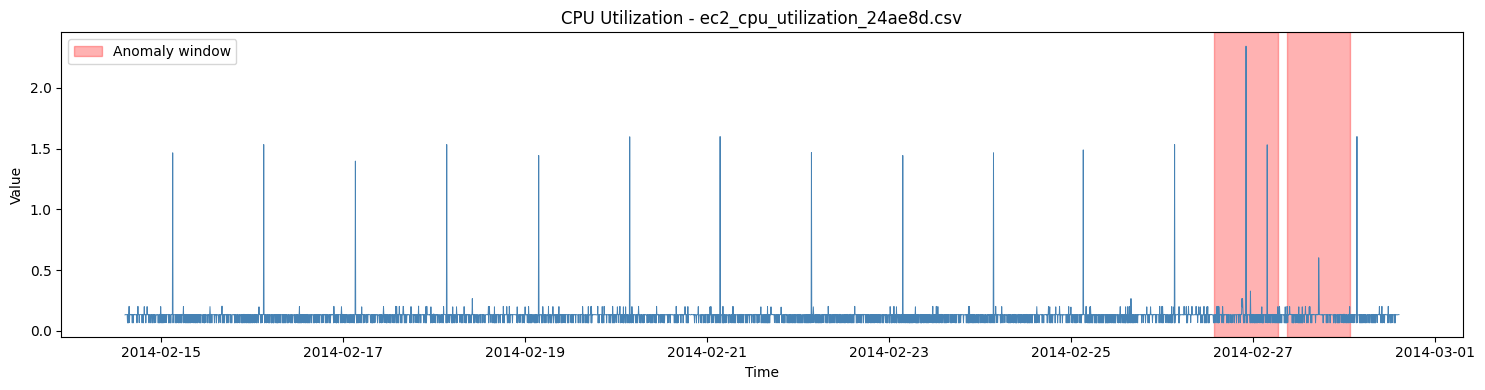

=== ec2_cpu_utilization_53ea38.csv ===
Shape: (4032, 1) | Missing points interpolated: 0
Value range: [1.6, 2.7] | Mean: 1.8 | Std: 0.1
Number of anomaly windows: 2
  - 2014-02-19 10:50:00 -> 2014-02-20 03:30:00  (duration: 0 days 16:40:00)
  - 2014-02-23 11:45:00 -> 2014-02-24 04:25:00  (duration: 0 days 16:40:00)


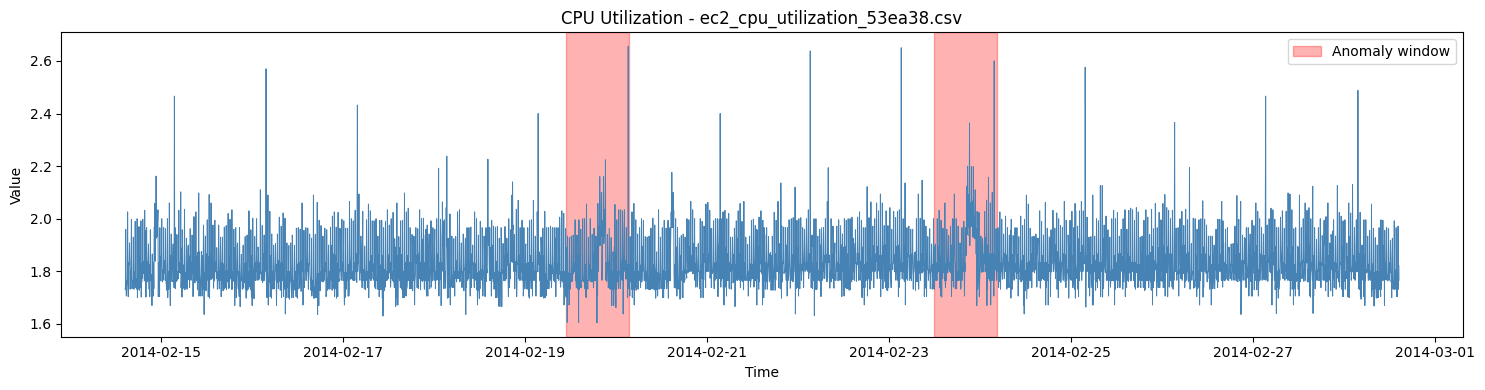

=== ec2_cpu_utilization_77c1ca.csv ===
Shape: (4032, 1) | Missing points interpolated: 0
Value range: [0.1, 99.9] | Mean: 10.5 | Std: 26.9
Number of anomaly windows: 1
  - 2014-04-08 17:30:00 -> 2014-04-10 03:00:00  (duration: 1 days 09:30:00)


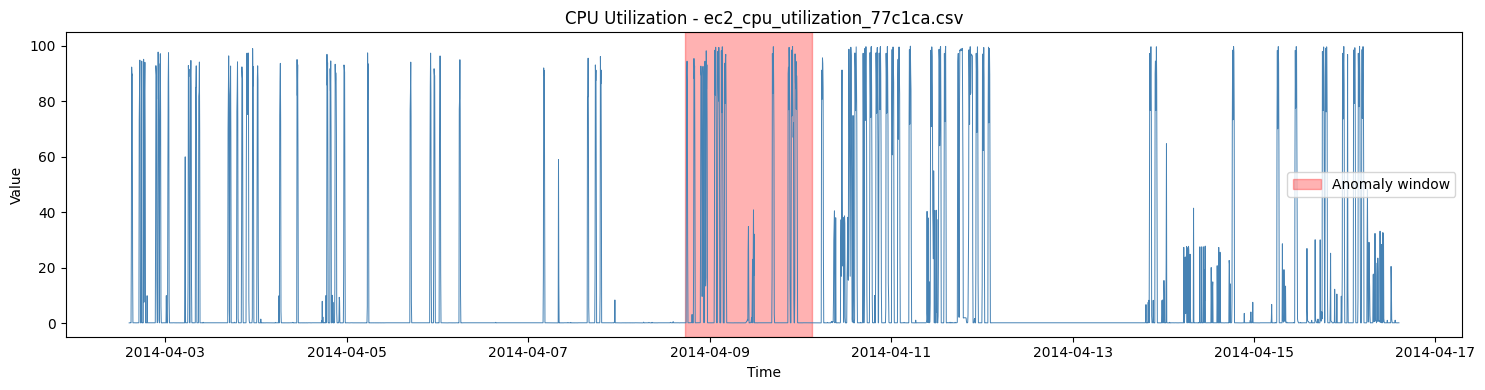

In [33]:
# Compare a few other CPU utilization files
other_files = [
    "ec2_cpu_utilization_24ae8d.csv",
    "ec2_cpu_utilization_53ea38.csv",
    "ec2_cpu_utilization_77c1ca.csv",
]

cleaned_data = {}
for fname in other_files:
    cleaned_data[fname] = explore_file(fname)

### Comparison of Anomaly Patterns Across Datasets

The analyzed datasets show very different normal behaviors and anomaly types. This highlights the need for adaptive anomaly detection methods rather than relying on a single detection strategy.

| File | Normal behavior | Anomaly pattern |
|------|-----------------|----------------|
| **825cc2** | High and stable CPU usage (~90%) | Sudden regime change: sharp drop followed by a low plateau |
| **24ae8d** | Near-zero usage (~0.1) with regular sparse peaks | Increase in peak frequency/intensity during the anomaly window |
| **53ea38** | Noisy but stable signal (~1.8, std ≈ 0.1) | Very subtle increase in variance/amplitude |
| **77c1ca** | Bimodal behavior: alternates between near 0 and high peaks (~95–100) | Transition from intermittent peaks to continuous high activity |

These examples show that anomalies can appear as level shifts, changes in frequency, variance changes, or different temporal patterns.

## Zoom on the harder case: ec2_cpu_utilization_53ea38.csv

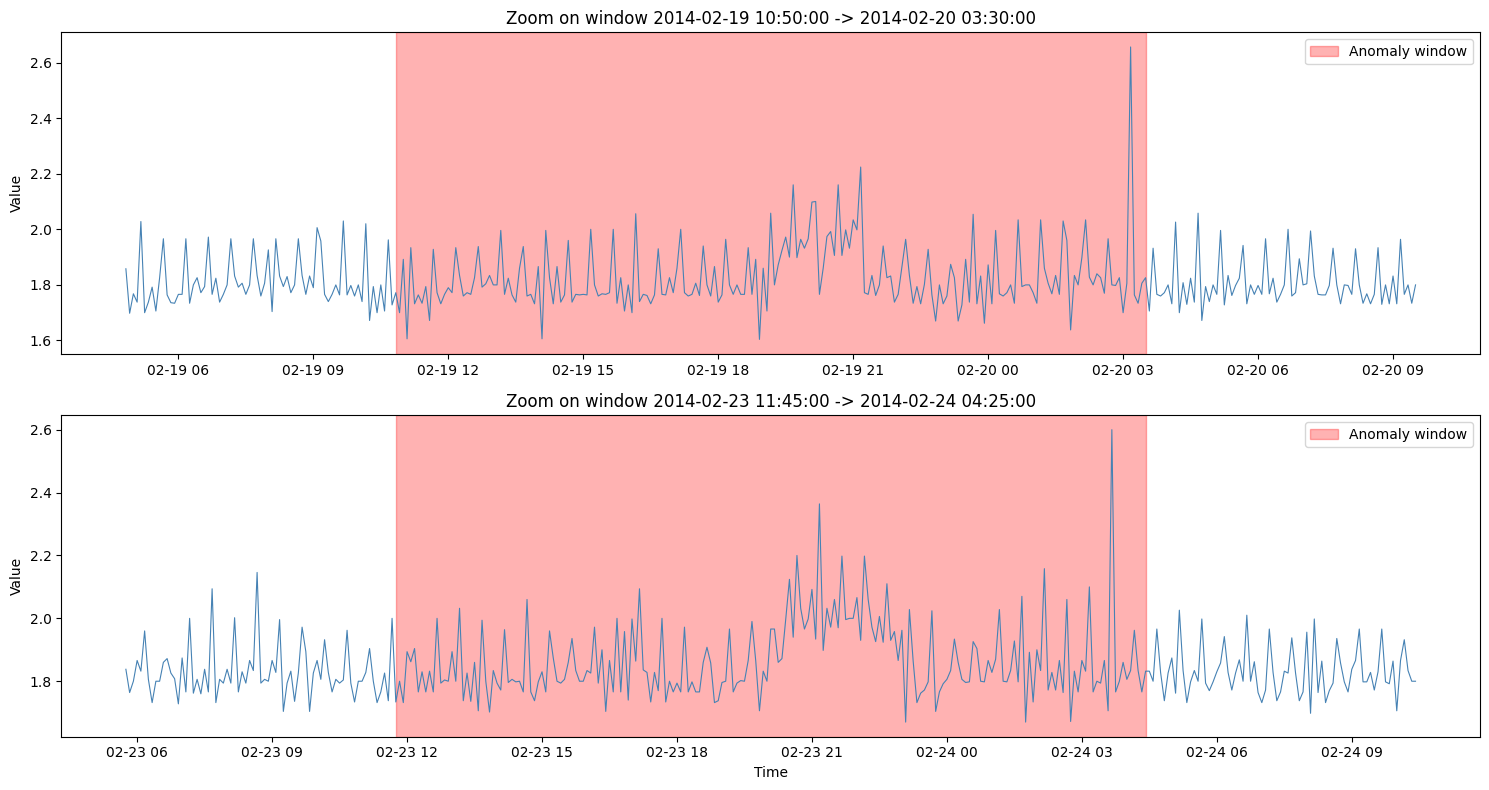

Value stats OUTSIDE anomaly windows:
count    3630.000000
mean        1.827182
std         0.098106
min         1.630000
25%         1.766000
50%         1.800000
75%         1.864000
max         2.650000
Name: value, dtype: float64

Value stats INSIDE anomaly windows:
count    402.000000
mean       1.850985
std        0.125942
min        1.604000
25%        1.766000
50%        1.806000
75%        1.927500
max        2.656000
Name: value, dtype: float64


In [34]:
fname = "ec2_cpu_utilization_53ea38.csv"
df_53ea38 = cleaned_data[fname]
windows_53ea38 = load_anomaly_windows(fname)

fig, axes = plt.subplots(len(windows_53ea38), 1, figsize=(15, 4 * len(windows_53ea38)))

for ax, (start, end) in zip(axes, windows_53ea38):
    # Add a margin before/after the window for context
    margin = pd.Timedelta(hours=6)
    zoom_start = start - margin
    zoom_end = end + margin

    df_zoom = df_53ea38.loc[zoom_start:zoom_end]

    ax.plot(df_zoom.index, df_zoom["value"], linewidth=0.8, color="steelblue")
    ax.axvspan(start, end, color="red", alpha=0.3, label="Anomaly window")
    ax.set_title(f"Zoom on window {start} -> {end}")
    ax.set_ylabel("Value")
    ax.legend()

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

# Compare distribution inside vs outside anomaly windows
df_53ea38["is_anomaly"] = 0
for start, end in windows_53ea38:
    df_53ea38.loc[start:end, "is_anomaly"] = 1

print("Value stats OUTSIDE anomaly windows:")
print(df_53ea38.loc[df_53ea38["is_anomaly"] == 0, "value"].describe())
print("\nValue stats INSIDE anomaly windows:")
print(df_53ea38.loc[df_53ea38["is_anomaly"] == 1, "value"].describe())

### Variance-Based Anomaly Analysis

The anomaly pattern in this dataset is different from previous examples:

- **Visual observation:** The anomaly appears as an increase in oscillation amplitude rather than a change in the average level. The signal becomes more variable during the anomaly window, with higher peaks before returning to normal.

- **Statistical analysis:**
  - Mean remains almost unchanged (**1.83 → 1.85**), confirming that the baseline level is stable.
  - Standard deviation increases (**0.098 → 0.126**, about **+28%**), showing a clear increase in local variability.
  - Maximum values are almost identical inside and outside the anomaly window, meaning extreme values alone are not sufficient for detection.

### Modeling Implication

This example shows that raw values are not always enough to detect anomalies. Features describing temporal behavior, such as **rolling standard deviation**, are more suitable for capturing variance changes. Therefore, features such as **value, rolling statistics, and point-to-point differences** will be considered for the Isolation Forest baseline model.